In [2]:
!pip install kaggle

In [3]:
! mkdir ~/.kaggle

In [4]:
! cp kaggle.json ~/.kaggle/

In [5]:
! chmod 600 ~/.kaggle/kaggle.json

In [6]:
! kaggle datasets list

ref                                                              title                                                size  lastUpdated          downloadCount  voteCount  usabilityRating  
---------------------------------------------------------------  --------------------------------------------------  -----  -------------------  -------------  ---------  ---------------  
ankushpanday1/heart-attack-in-youth-of-india                     Heart attack in youth of India                      298KB  2025-01-02 15:20:31           1096         33  1.0              
oktayrdeki/heart-disease                                         Heart Disease                                       568KB  2024-12-29 13:26:49           1336         36  1.0              
stealthtechnologies/predict-student-performance-dataset          Predict Student Performance                          12KB  2024-12-26 12:57:04           1657         43  1.0              
umerhaddii/apple-stock-data-2025                       

In [7]:
! kaggle datasets download -d elakiricoder/gender-classification-dataset

Dataset URL: https://www.kaggle.com/datasets/elakiricoder/gender-classification-dataset
License(s): CC0-1.0
  0% 0.00/19.0k [00:00<?, ?B/s]
100% 19.0k/19.0k [00:00<00:00, 29.6MB/s]


In [11]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, accuracy_score
from sklearn.neighbors import KNeighborsClassifier


In [21]:
import os
import zipfile
os.mkdir('dataset')
dataset_dir = 'dataset'

In [22]:
target_file = 'gender-classification-dataset.zip'

In [23]:
extracting = zipfile.ZipFile(target_file, 'r')
extracting.extractall(dataset_dir)
extracting.close()

In [25]:
df = pd.read_csv(f'{dataset_dir}/gender_classification_v7.csv')
df = df.drop_duplicates()


In [26]:
df.head()


,long_hair,forehead_width_cm,forehead_height_cm,nose_wide,nose_long,lips_thin,distance_nose_to_lip_long,gender
0,1,11.8,6.1,1,0,1,1,Male
1,0,14.0,5.4,0,0,1,0,Female
2,0,11.8,6.3,1,1,1,1,Male
3,0,14.4,6.1,0,1,1,1,Male
4,1,13.5,5.9,0,0,0,0,Female


In [27]:
df.tail()

,long_hair,forehead_width_cm,forehead_height_cm,nose_wide,nose_long,lips_thin,distance_nose_to_lip_long,gender
4986,1,11.7,6.1,1,1,0,1,Male
4990,1,12.6,5.7,0,0,1,0,Female
4992,1,14.1,7.0,1,1,1,1,Male
4993,1,11.6,5.9,0,0,0,1,Female
4995,1,12.3,6.9,0,1,1,1,Male


In [28]:
df.columns


Index(['long_hair', 'forehead_width_cm', 'forehead_height_cm', 'nose_wide',
       'nose_long', 'lips_thin', 'distance_nose_to_lip_long', 'gender'],
      dtype='object')

In [29]:
df.info()


<class 'pandas.core.frame.DataFrame'>
Index: 3233 entries, 0 to 4995
Data columns (total 8 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   long_hair                  3233 non-null   int64  
 1   forehead_width_cm          3233 non-null   float64
 2   forehead_height_cm         3233 non-null   float64
 3   nose_wide                  3233 non-null   int64  
 4   nose_long                  3233 non-null   int64  
 5   lips_thin                  3233 non-null   int64  
 6   distance_nose_to_lip_long  3233 non-null   int64  
 7   gender                     3233 non-null   object 
dtypes: float64(2), int64(5), object(1)
memory usage: 227.3+ KB


In [30]:
df.describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
long_hair,3233.0,0.82,0.38,0.0,1.0,1.0,1.0,1.0
forehead_width_cm,3233.0,13.22,1.12,11.4,12.3,13.2,14.1,15.5
forehead_height_cm,3233.0,5.97,0.55,5.1,5.5,5.9,6.4,7.1
nose_wide,3233.0,0.54,0.50,0.0,0.0,1.0,1.0,1.0
nose_long,3233.0,0.56,0.50,0.0,0.0,1.0,1.0,1.0
lips_thin,3233.0,0.54,0.50,0.0,0.0,1.0,1.0,1.0
distance_nose_to_lip_long,3233.0,0.55,0.50,0.0,0.0,1.0,1.0,1.0


In [31]:
df.describe(include="all").T.round(2)

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
long_hair,3233.0,NaN,NaN,NaN,0.822456,0.382188,0.0,1.0,1.0,1.0,1.0
forehead_width_cm,3233.0,NaN,NaN,NaN,13.217198,1.115993,11.4,12.3,13.2,14.1,15.5
forehead_height_cm,3233.0,NaN,NaN,NaN,5.966038,0.549789,5.1,5.5,5.9,6.4,7.1
nose_wide,3233.0,NaN,NaN,NaN,0.536344,0.498755,0.0,0.0,1.0,1.0,1.0
nose_long,3233.0,NaN,NaN,NaN,0.557686,0.496738,0.0,0.0,1.0,1.0,1.0
lips_thin,3233.0,NaN,NaN,NaN,0.538509,0.498592,0.0,0.0,1.0,1.0,1.0
distance_nose_to_lip_long,3233.0,NaN,NaN,NaN,0.545314,0.498019,0.0,0.0,1.0,1.0,1.0
gender,3233,2,Male,1783,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [32]:
numerical_vars = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_vars = df.select_dtypes(include=['object']).columns.tolist()
print('Numerical variables:', numerical_vars)
print('Categorical variables:', categorical_vars)

Numerical variables: ['long_hair', 'forehead_width_cm', 'forehead_height_cm', 'nose_wide', 'nose_long', 'lips_thin', 'distance_nose_to_lip_long']
Categorical variables: ['gender']


In [33]:
print(df.select_dtypes(include=['object']).nunique())

gender    2
dtype: int64


In [34]:
missing_df =  df.isnull().sum().to_frame().rename(columns={0:"Total No. of Missing Values"})
missing_df["% of Missing Values"] = round((missing_df["Total No. of Missing Values"]/len( df))*100,2)
missing_df

,Total No. of Missing Values,% of Missing Values
long_hair,0,0.0
forehead_width_cm,0,0.0
forehead_height_cm,0,0.0
nose_wide,0,0.0
nose_long,0,0.0
lips_thin,0,0.0
distance_nose_to_lip_long,0,0.0
gender,0,0.0


In [35]:
df[df.duplicated(keep=False)]

,long_hair,forehead_width_cm,forehead_height_cm,nose_wide,nose_long,lips_thin,distance_nose_to_lip_long,gender


In [36]:
df.drop_duplicates(inplace=True)

In [37]:
df.shape

(3233, 8)

In [38]:
df['gender'].value_counts()

,count
gender,
Male,1783
Female,1450


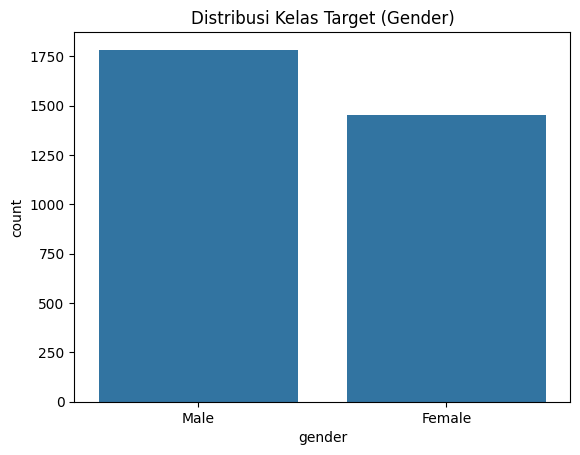

In [39]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x='gender', data=df)
plt.title('Distribusi Kelas Target (Gender)')
plt.show()

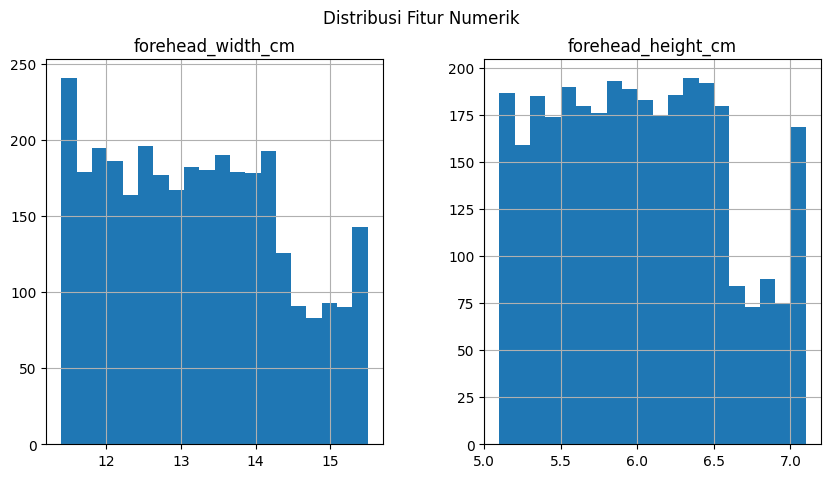

In [42]:
df[['forehead_width_cm', 'forehead_height_cm']].hist(bins=20, figsize=(10, 5))
plt.suptitle('Distribusi Fitur Numerik')
plt.show()

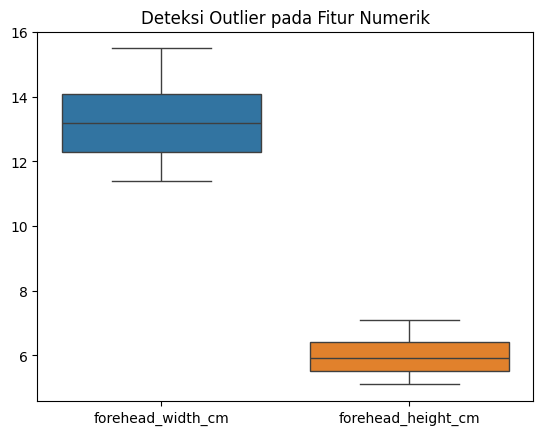

In [46]:
sns.boxplot(data=df[['forehead_width_cm', 'forehead_height_cm']])
plt.title('Deteksi Outlier pada Fitur Numerik')
plt.show()

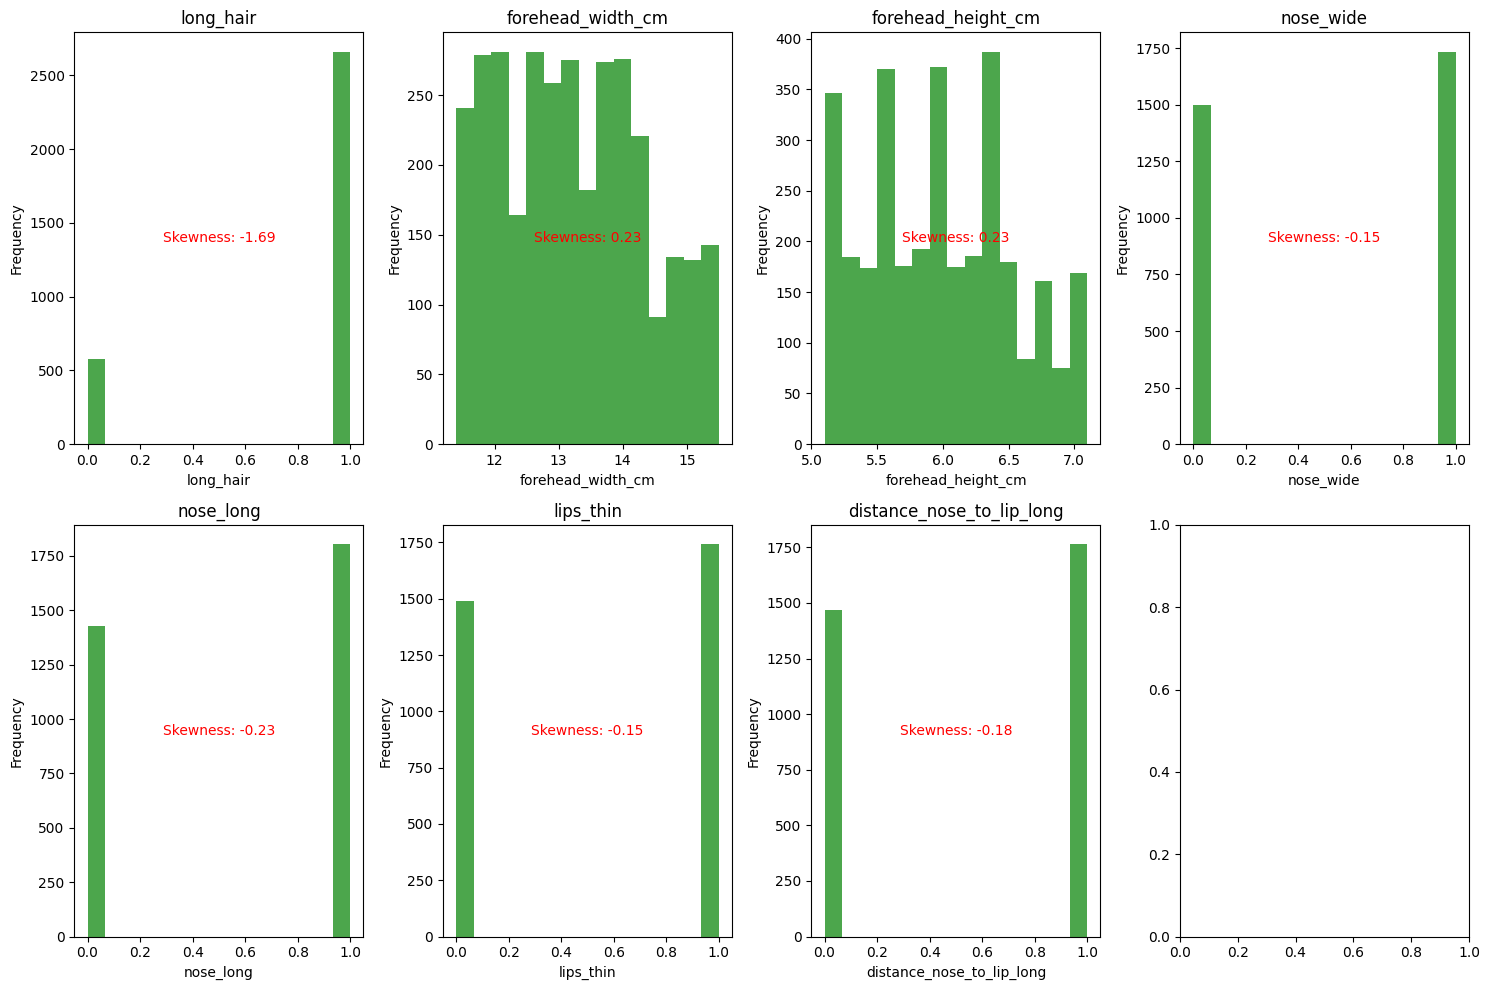

Skewness:
long_hair                   -1.688467
forehead_width_cm            0.226676
forehead_height_cm           0.225240
nose_wide                   -0.145829
nose_long                   -0.232404
lips_thin                   -0.154567
distance_nose_to_lip_long   -0.182089
dtype: float64


In [40]:
# Calculate skewness for numerical columns
skewness = df.select_dtypes(include=['int64', 'float64']).skew()

# Count the number of numerical columns
num_cols_count = len(df.select_dtypes(include=['int64', 'float64']).columns)

# Determine the layout for subplots
num_rows = (num_cols_count + 3) // 4  # Adjust the number of columns in each row
num_cols = min(4, num_cols_count)  # Maximum of 4 columns in each row

# Plot histograms for numerical columns to visualize distributions and identify anomalies
fig, axes = plt.subplots(num_rows, num_cols, figsize=(15, 10))

for i in range(num_rows):
    for j in range(num_cols):
        col_idx = i * num_cols + j
        if col_idx < num_cols_count:
            col = df.select_dtypes(include=['int64', 'float64']).columns[col_idx]
            axes[i, j].hist(df[col], bins=15, color='green', alpha=0.7)
            axes[i, j].set_title(f'{col}')
            axes[i, j].set_xlabel(col)
            axes[i, j].set_ylabel('Frequency')

            # Compute skewness
            skew_val = skewness[col]

            # Plot skewness value in the center of plot
            axes[i, j].text(0.5, 0.5, f'Skewness: {skew_val:.2f}', horizontalalignment='center',
                            verticalalignment='center', transform=axes[i, j].transAxes, fontsize=10, color='red')

plt.tight_layout()
plt.show()

# Print skewness values
print("Skewness:")
print(skewness)

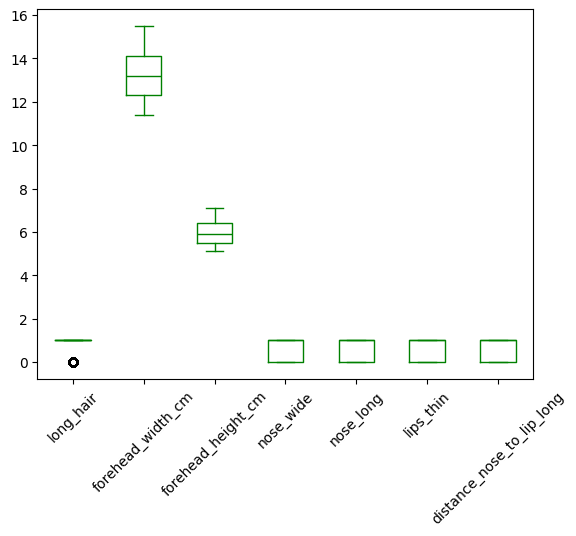

In [41]:
# Plot the boxplot with rotated text labels
df.plot(kind='box', rot=45,color='green')

# Show the plot
plt.show()

<ipython-input-238-7c90968db9c9>:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=df[column],palette='rainbow')


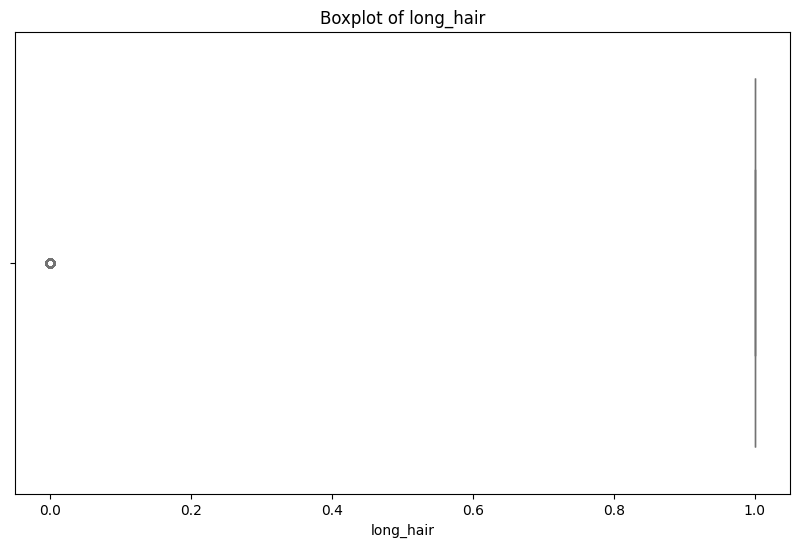

<ipython-input-238-7c90968db9c9>:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=df[column],palette='rainbow')


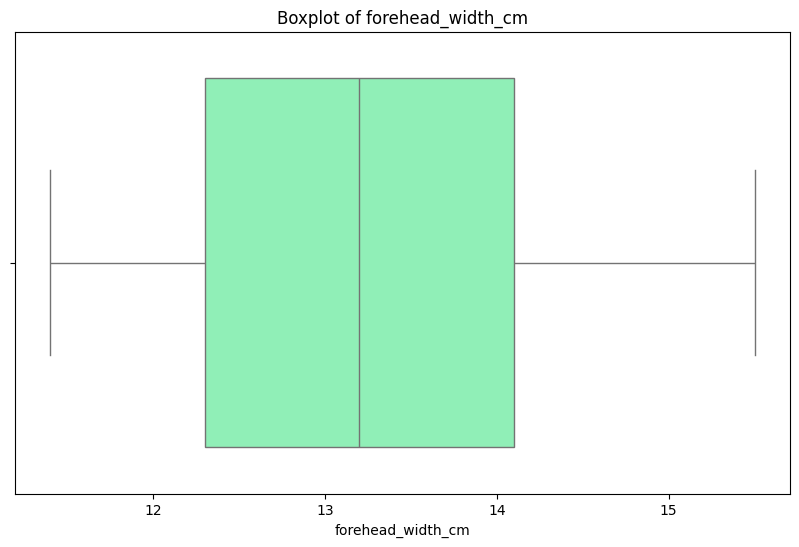

<ipython-input-238-7c90968db9c9>:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=df[column],palette='rainbow')


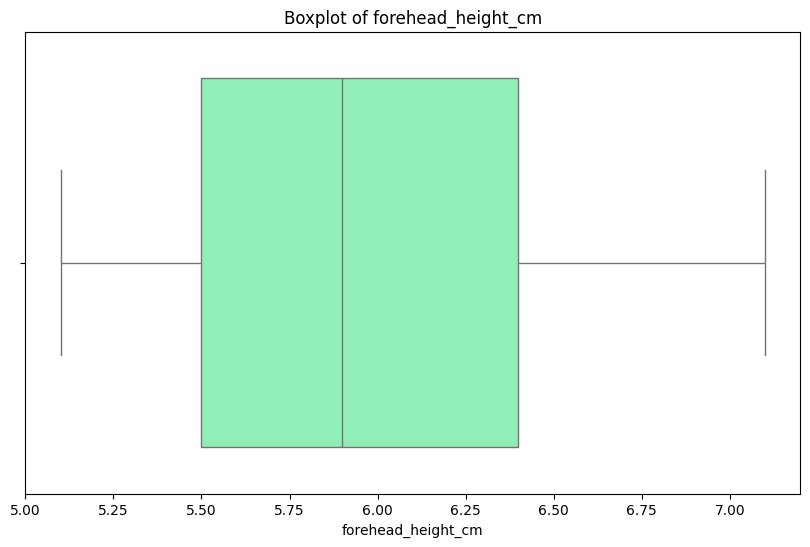

<ipython-input-238-7c90968db9c9>:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=df[column],palette='rainbow')


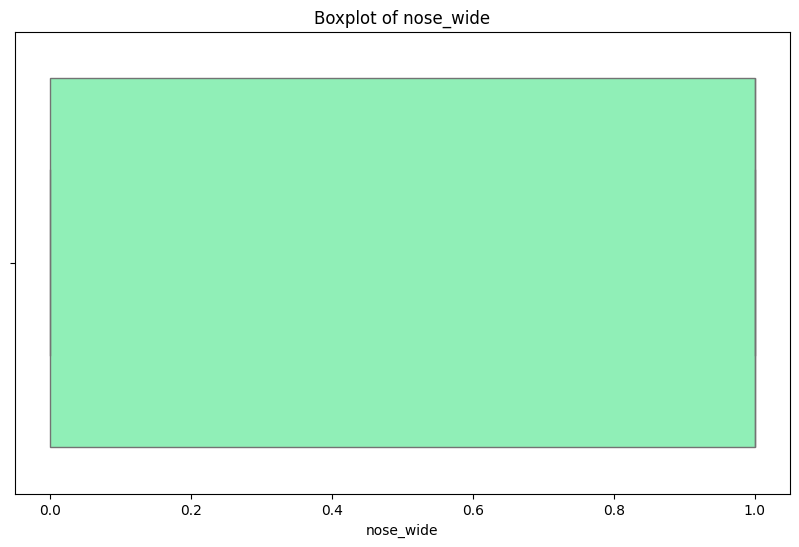

<ipython-input-238-7c90968db9c9>:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=df[column],palette='rainbow')


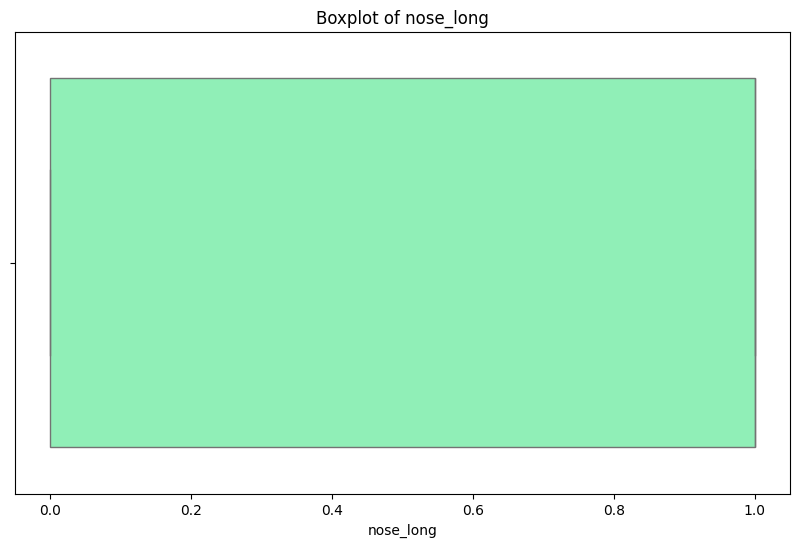

<ipython-input-238-7c90968db9c9>:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=df[column],palette='rainbow')


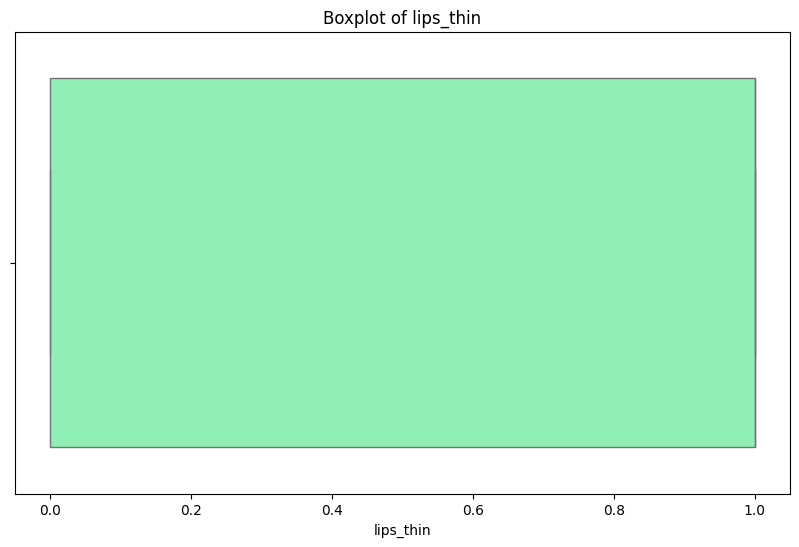

<ipython-input-238-7c90968db9c9>:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=df[column],palette='rainbow')


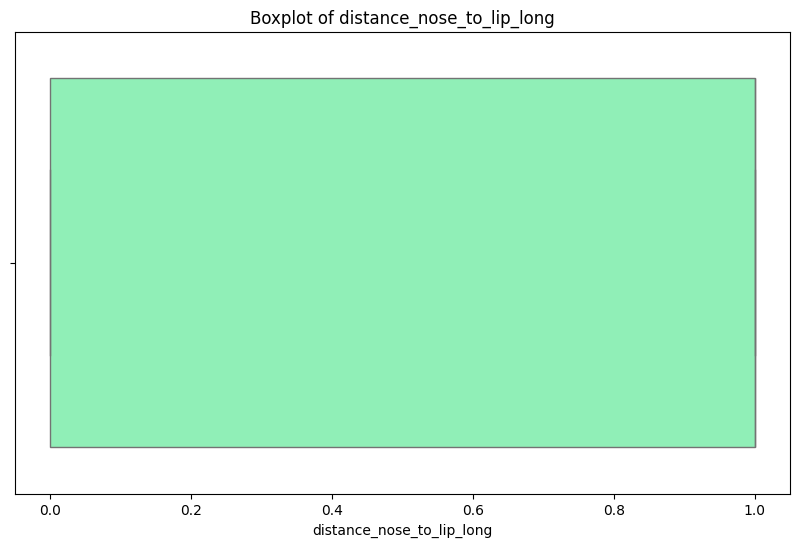

<ipython-input-238-7c90968db9c9>:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=df[column],palette='rainbow')


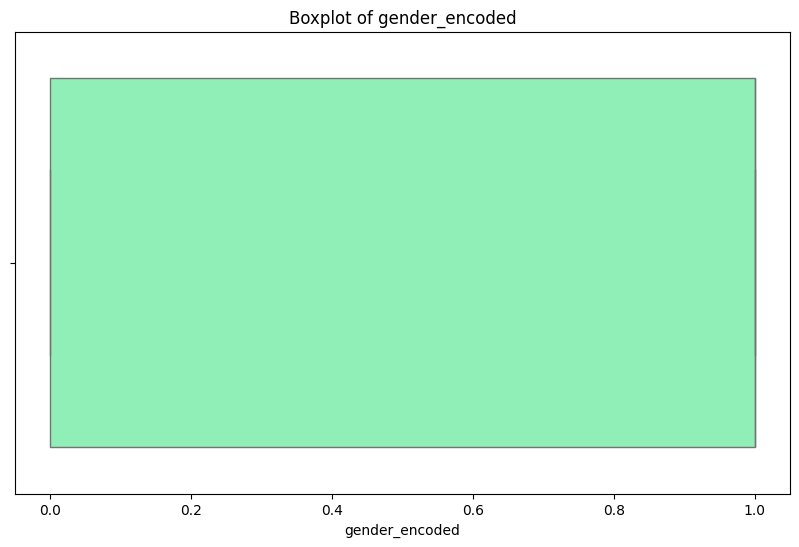

In [ ]:
# Filter numeric columns
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns

# Plotting boxplots for each numerical feature to identify outliers
for column in numeric_cols:
    plt.figure(figsize=(10, 6))
    sns.boxplot(x=df[column],palette='rainbow')
    plt.title(f'Boxplot of {column}')
    plt.show()

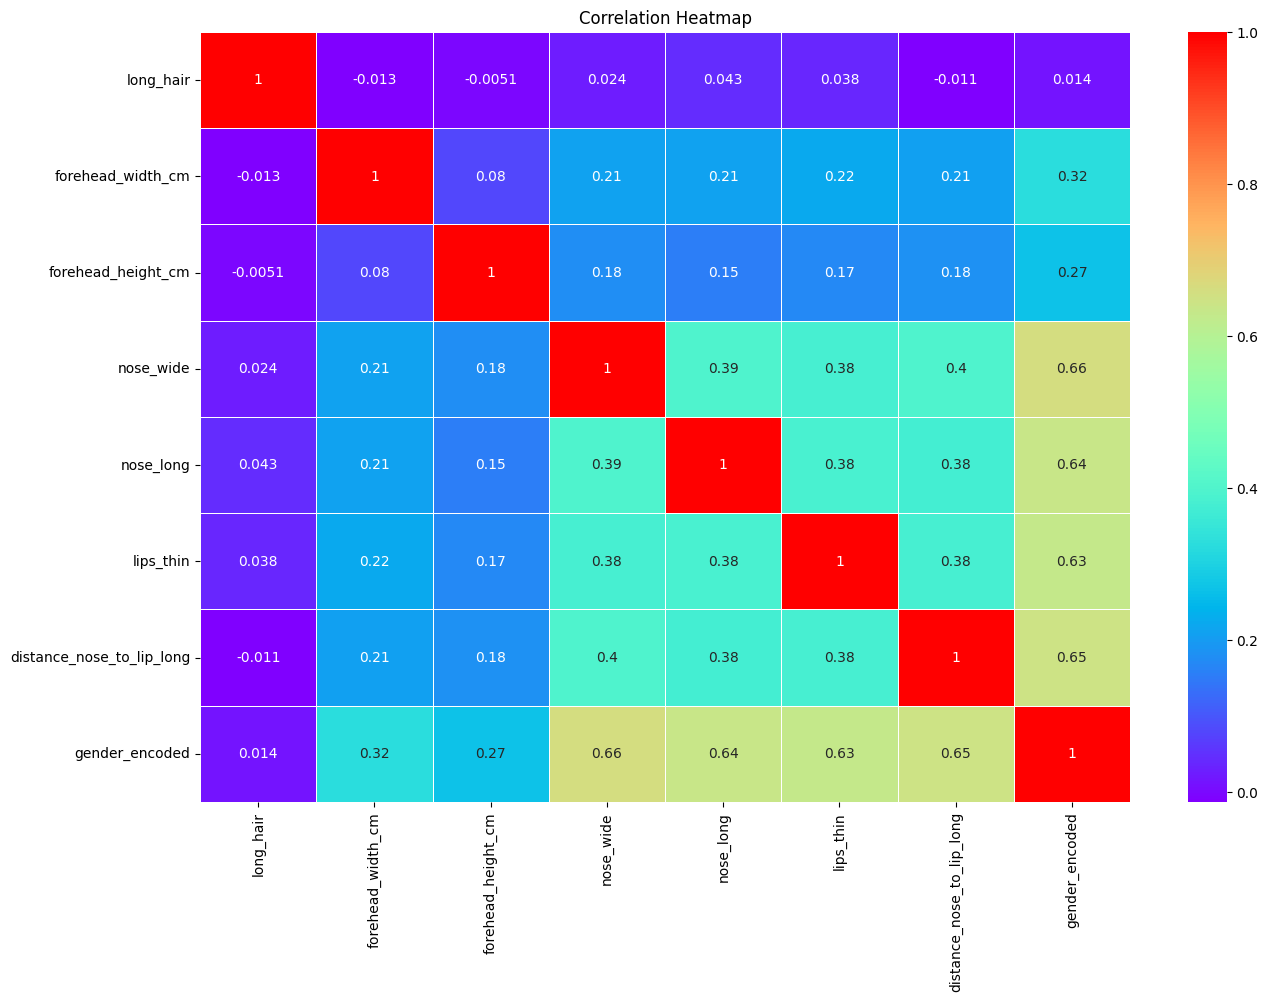

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Select only numeric columns
df_numeric = df.select_dtypes(include=[float, int])

# Compute the correlation matrix
corr_matrix = df_numeric.corr()

# Plot the heatmap
plt.figure(figsize=(15,10))
sns.heatmap(corr_matrix, annot=True, linewidths=0.5, cmap="rainbow")
plt.title('Correlation Heatmap')
plt.show()

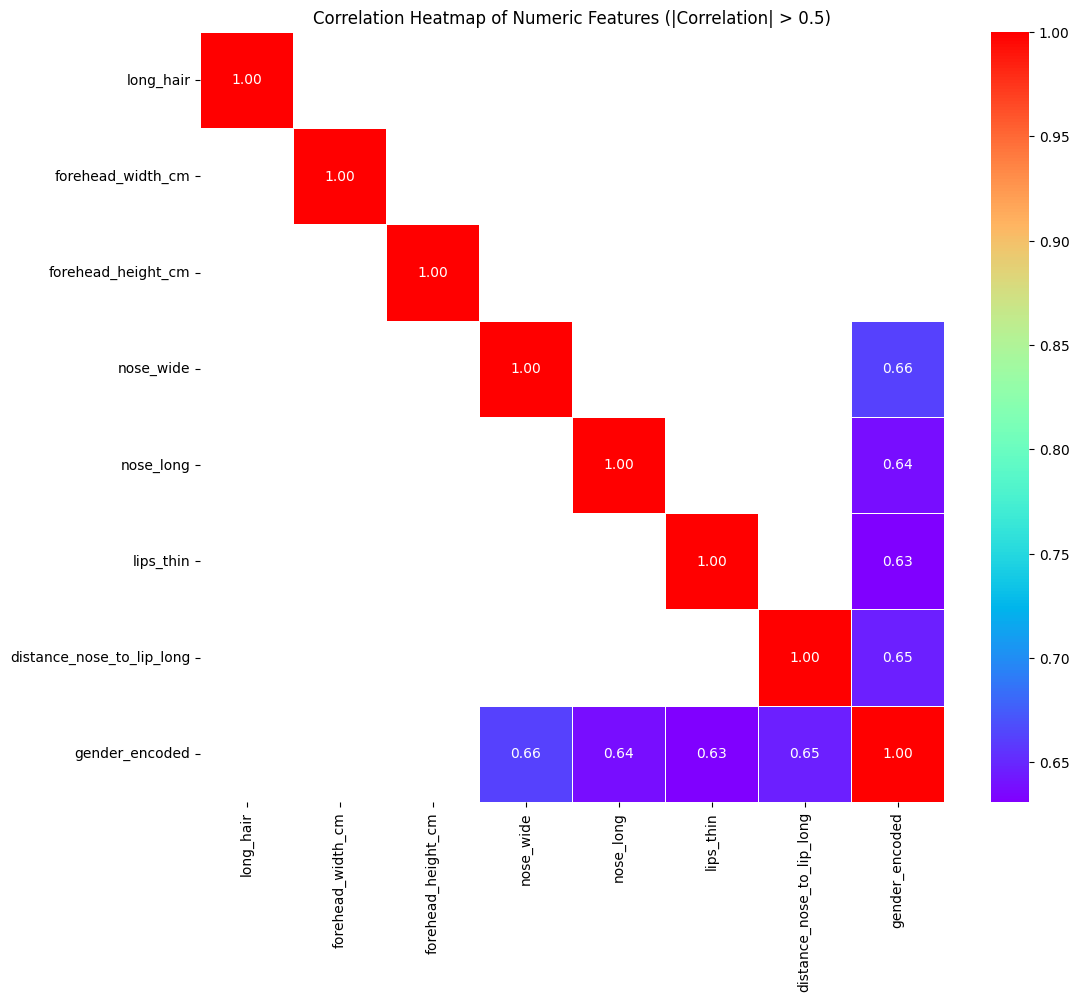

In [ ]:
numeric_columns = df.select_dtypes(include=['int64', 'float64'])

corr_matrix = numeric_columns.corr()

corr_matrix_filtered = corr_matrix[(corr_matrix > 0.5) | (corr_matrix < -0.5)]

plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix_filtered, annot=True, cmap='rainbow', fmt=".2f", linewidths=0.5)
plt.title('Correlation Heatmap of Numeric Features (|Correlation| > 0.5)')
plt.show()

<ipython-input-241-a8693058ea1d>:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=column, data=df,palette='rainbow')


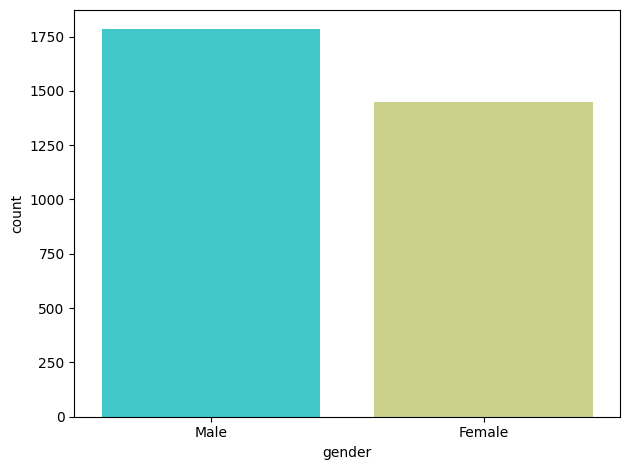

In [ ]:
for column in df.select_dtypes(include=['object']):
    sns.countplot(x=column, data=df,palette='rainbow')
    plt.tight_layout()
    plt.show()

In [ ]:

m_col=['long_hair','forehead_width_cm','forehead_height_cm','nose_wide',
       'nose_long','lips_thin','distance_nose_to_lip_long','gender']

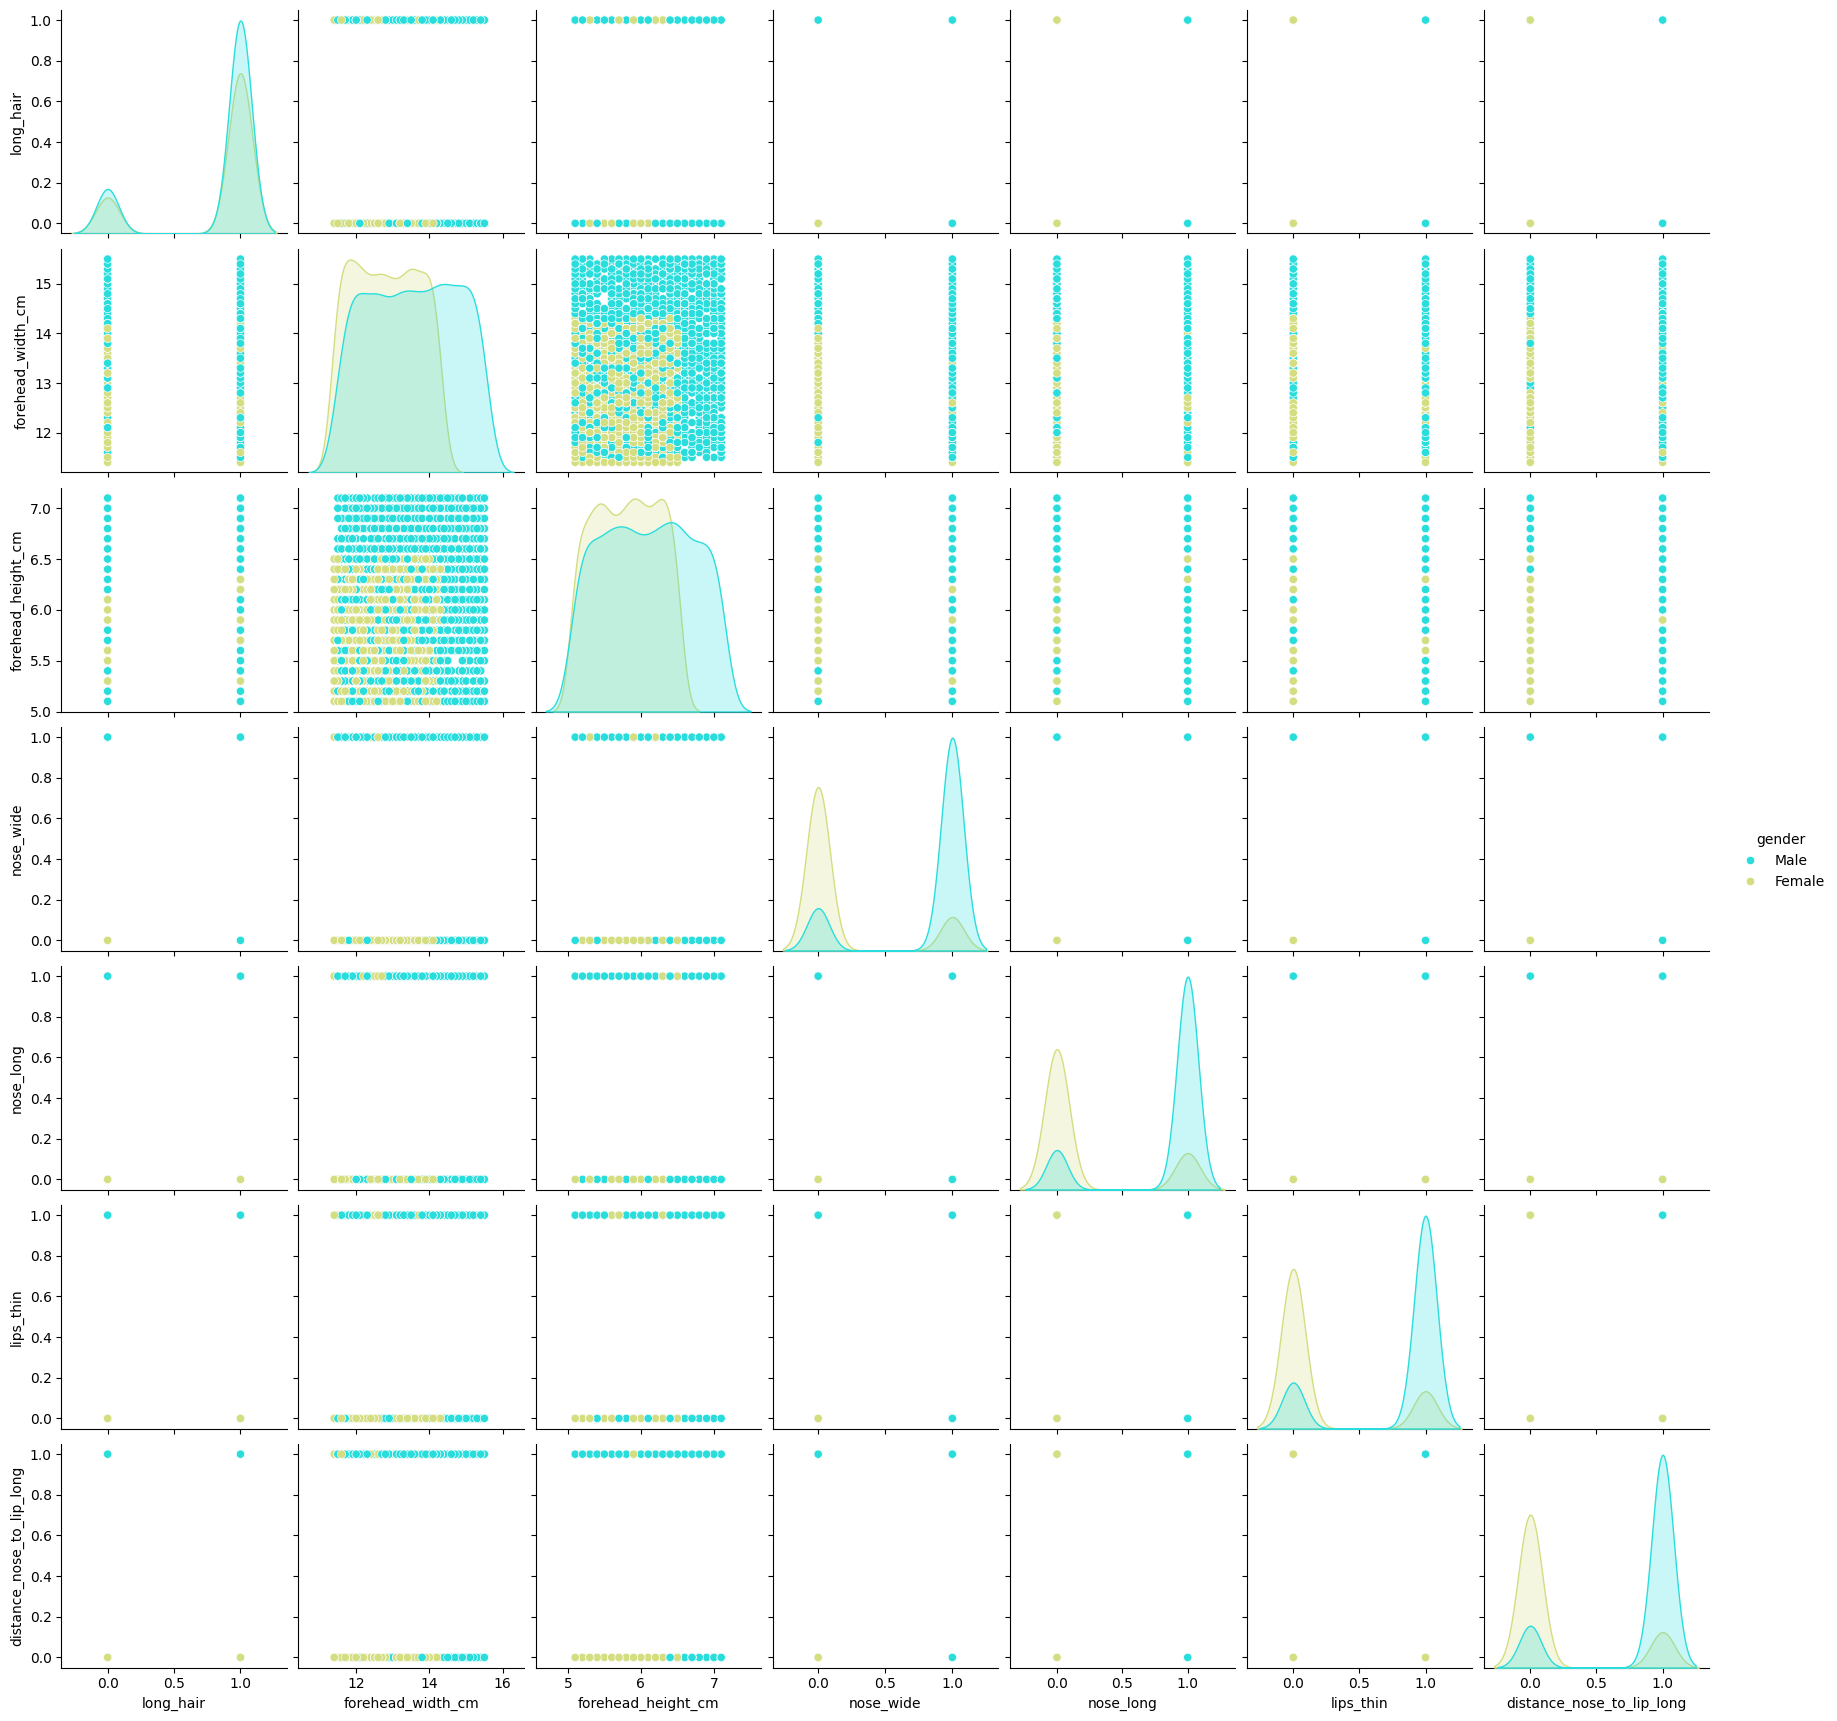

In [ ]:
sns.pairplot(df[m_col],hue='gender',palette='rainbow')

In [ ]:
X

,forehead_width_cm,forehead_height_cm,distance_nose_to_lip_long,lips_thin,long_hair,nose_long,nose_wide
0,11.8,6.1,1,1,1,0,1
1,14.0,5.4,0,1,0,0,0
2,11.8,6.3,1,1,0,1,1
3,14.4,6.1,1,1,0,1,0
4,13.5,5.9,0,0,1,0,0
...,...,...,...,...,...,...,...
4986,11.7,6.1,1,0,1,1,1
4990,12.6,5.7,0,1,1,0,0
4992,14.1,7.0,1,1,1,1,1
4993,11.6,5.9,1,0,1,0,0


In [ ]:
Y

,gender_encoded
0,1
1,0
2,1
3,1
4,0
...,...
4986,1
4990,0
4992,1
4993,0


In [ ]:
from sklearn.model_selection import train_test_split
X_train,X_test,Y_train,Y_test= train_test_split(X,Y,test_size=0.40,random_state=1)

In [ ]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier()
knn.fit(X_train, Y_train)

KNeighborsClassifier()

In [ ]:
prediction2 = knn.predict(X_test)

In [ ]:
from sklearn.metrics import accuracy_score
knn_acc = accuracy_score(Y_test, prediction2)
print("Accuracy score with test dataset for K Neighbors Classifier:",knn_acc)

Accuracy score with test dataset for K Neighbors Classifier: 0.9559505409582689


In [ ]:
from sklearn.metrics import classification_report,confusion_matrix

print("Confusion matrix; \n",confusion_matrix(Y_test,prediction2))
print("\n")
print('Classification report: \n',classification_report(Y_test,prediction2))

Confusion matrix; 
 [[550  20]
 [ 37 687]]


Classification report: 
               precision    recall  f1-score   support

           0       0.94      0.96      0.95       570
           1       0.97      0.95      0.96       724

    accuracy                           0.96      1294
   macro avg       0.95      0.96      0.96      1294
weighted avg       0.96      0.96      0.96      1294



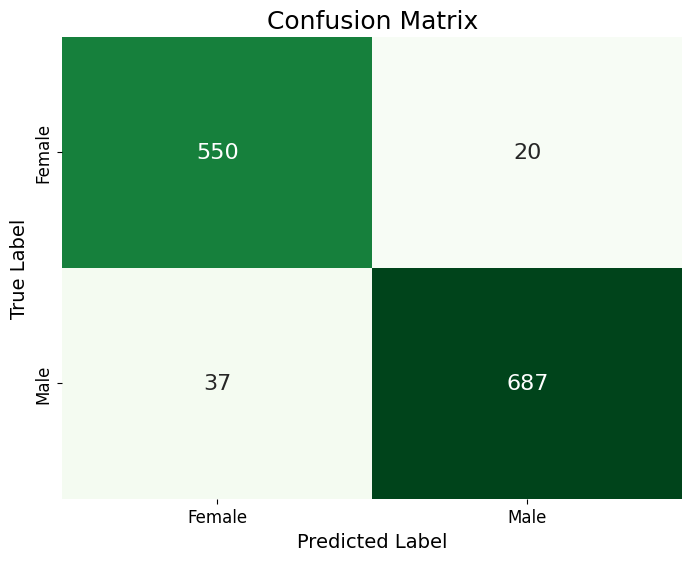

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

cm = [[550, 20], [37, 687]]

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Greens", cbar=False, annot_kws={"size": 16})
plt.title("Confusion Matrix", fontsize=18)
plt.xlabel("Predicted Label", fontsize=14)
plt.ylabel("True Label", fontsize=14)
plt.xticks([0.5, 1.5], ["Female", "Male"], fontsize=12)
plt.yticks([0.5, 1.5], ["Female", "Male"], fontsize=12)
plt.show()


In [ ]:
test_data_female = pd.DataFrame([{
    'forehead_width_cm': 13.0,
    'forehead_height_cm': 14.5,
    'distance_nose_to_lip_long': 0,
    'lips_thin': 0,
    'long_hair': 1,
    'nose_long': 0,
    'nose_wide': 0
}])

test_data_male = pd.DataFrame([{
    'forehead_width_cm': 15.0,
    'forehead_height_cm': 13.0,
    'distance_nose_to_lip_long': 1,
    'lips_thin': 1,
    'long_hair': 0,
    'nose_long': 1,
    'nose_wide': 1
}])

test_data_synthetic = pd.concat([test_data_female, test_data_male], ignore_index=True)

test_data_scaled = scaler.transform(test_data_synthetic)

predictions = knn_classifier.predict(test_data_scaled)

test_data_synthetic['Prediksi'] = ["Laki-laki" if p == 1 else "Perempuan" for p in predictions]
print("Hasil Prediksi Data Buatan:")
print(test_data_synthetic)

Hasil Prediksi Data Buatan:
   forehead_width_cm  forehead_height_cm  distance_nose_to_lip_long  \
0               13.0                14.5                          0   
1               15.0                13.0                          1   

   lips_thin  long_hair  nose_long  nose_wide   Prediksi  
0          0          1          0          0  Perempuan  
1          1          0          1          1  Laki-laki  


/usr/local/lib/python3.10/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but KNeighborsClassifier was fitted with feature names
  warnings.warn(


In [ ]:
with open('knn_model.pkl', 'wb') as model_file:
    pickle.dump(knn_classifier, model_file)
print("Model KNN berhasil disimpan sebagai 'knn_model.pkl'.")

with open('scaler.pkl', 'wb') as scaler_file:
    pickle.dump(scaler, scaler_file)
print("Scaler berhasil disimpan sebagai 'scaler.pkl'.")


Model KNN berhasil disimpan sebagai 'knn_model.pkl'.
Scaler berhasil disimpan sebagai 'scaler.pkl'.
